# Notebook 05 - NLP Tag Genome & Free Tags

Pipeline NLP end-to-end di atas dua sumber teks MovieLens:

1. **Free-text tags** (2.33 juta tag-rating mentah) -> pembersihan (lowercase,
   strip non-word, dedup per-user-movie-tag, lemmatization WordNet) ->
   per-movie tag document.
2. **Tag genome** (1128 dimensi relevance per film) -> UMAP 2D -> HDBSCAN
   cluster.

Analitik yang dihasilkan:
- Topic modeling `BERTopic` (sentence-transformers + UMAP + HDBSCAN internal) pada
  tag-document per film.
- Sentence embedding `all-MiniLM-L6-v2` -> FAISS untuk semantic search bebas query.
- WordCloud per genre, co-occurrence network top-80 tag.

Semua artifact tersimpan di `data/processed/nlp/`, figur di `reports/figures/24-28`.
Dijalankan ulang via `python scripts/run_nlp.py`.


In [1]:
import json, sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image, display

FIG = ROOT / "reports" / "figures"
NLP = ROOT / "data" / "processed" / "nlp"

summary = json.loads((NLP / "summary.json").read_text())
pd.DataFrame([summary]).T.rename(columns={0: "value"})


,value
tags_clean_rows,2322537
movies_with_docs,39960
movies_embedded,30000
bertopic_n_topics,94
genome_clusters,2
cooccurrence_edges,1634


## 1. Pembersihan tag & pembentukan dokumen per-film

`src/nlp.py::clean_tags` menormalisasi tag bebas: lowercase, hapus karakter
non-kata, collapse whitespace, dedup `(userId, movieId, tag)`, lemmatize
WordNet. Hasil: `tags_clean.parquet` + `movie_tag_docs.parquet` (satu baris
per film, kolom `doc` = gabungan tag yang muncul pada film tersebut).


In [2]:
tags = pl.read_parquet(NLP / "tags_clean.parquet")
docs = pl.read_parquet(NLP / "movie_tag_docs.parquet")
print("tags_clean:", tags.shape, " |  movie_tag_docs:", docs.shape)
docs.sort("total_tags", descending=True).head(5).to_pandas()


tags_clean: (2322537, 5)  |  movie_tag_docs: (39960, 5)


,movieId,tags,counts,doc,total_tags
0,260,"[sci-fi, science fiction, space, classic, spac...","[1112, 492, 487, 477, 414, 384, 320, 281, 260,...",sci-fi science fiction space classic space adv...,11143
1,79132,"[alternate reality, thought-provoking, mindfuc...","[505, 501, 409, 403, 316, 303, 293, 290, 272, ...",alternate reality thought-provoking mindfuck v...,8941
2,296,"[quentin tarantino, dark comedy, nonlinear, mu...","[561, 396, 309, 288, 269, 219, 201, 185, 180, ...",quentin tarantino dark comedy nonlinear multip...,8727
3,2571,"[sci-fi, virtual reality, thought-provoking, d...","[442, 353, 336, 323, 313, 279, 265, 252, 232, ...",sci-fi virtual reality thought-provoking dysto...,7560
4,2959,"[twist ending, psychology, dark comedy, social...","[494, 393, 381, 319, 294, 280, 277, 268, 266, ...",twist ending psychology dark comedy social com...,7459


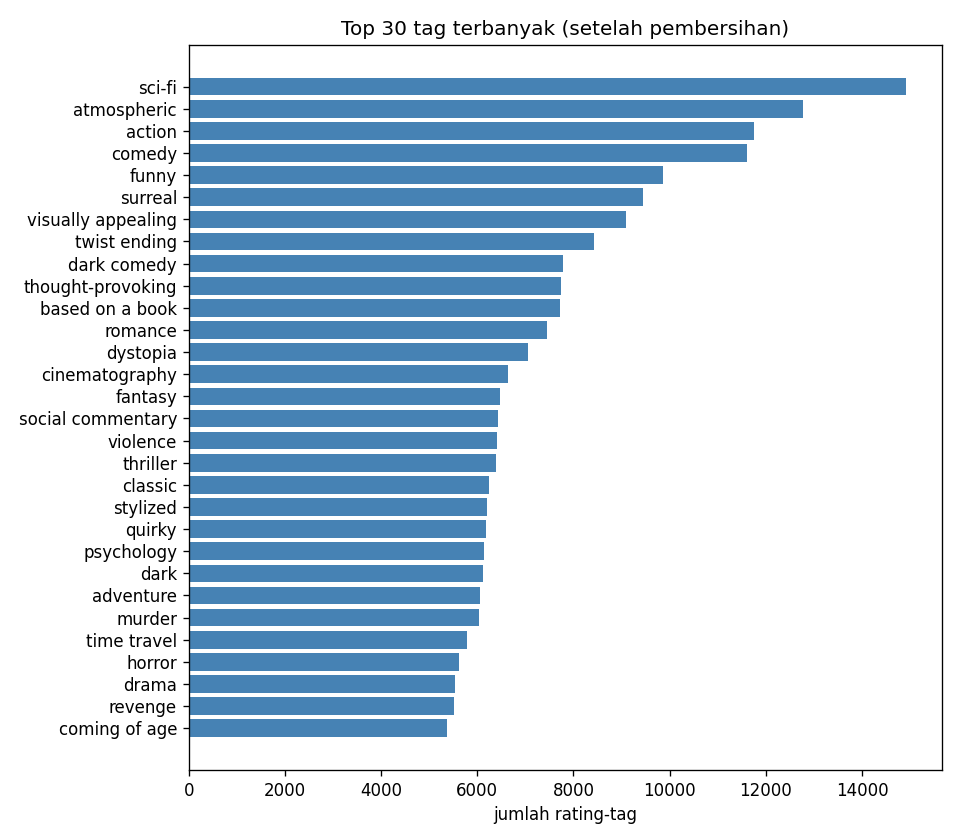

In [3]:
display(Image(filename=str(FIG / "24_top_tags.png")))


## 2. Topic modeling - BERTopic

BERTopic di-fit pada 30K film dengan tag terbanyak. Vectorizer: CountVectorizer
bigram + stopwords English + `min_df=5`. Output: 94 topik semantik
(ex: *horror-zombie*, *marvel-superhero*, *anime-studio-ghibli*).
Assignment per film tersimpan di `bertopic_topics.parquet`.


In [4]:
info = pd.read_csv(NLP / "bertopic_info.csv")
print("Jumlah topik (tanpa noise):", (info['Topic'] >= 0).sum())
info[info['Topic'] >= 0].head(15)[['Topic', 'Count', 'Name']]


Jumlah topik (tanpa noise): 94


,Topic,Count,Name
1,0,2550,0_reference_man_female_shot
2,1,780,1_gay_lgbt_homosexuality_lesbian
3,2,619,2_martial_martial art_art_fu
4,3,585,3_animation_animal_disney_cartoon
5,4,535,4_nudity_nudity topless_topless_frontal
6,5,518,5_japan_japanese_anime_samurai
7,6,469,6_western_horse_arizona_outlaw
8,7,457,7_comedy_funny_humor_romantic
9,8,426,8_russian_russia_ussr_soviet
10,9,411,9_nazi_war_world war_world


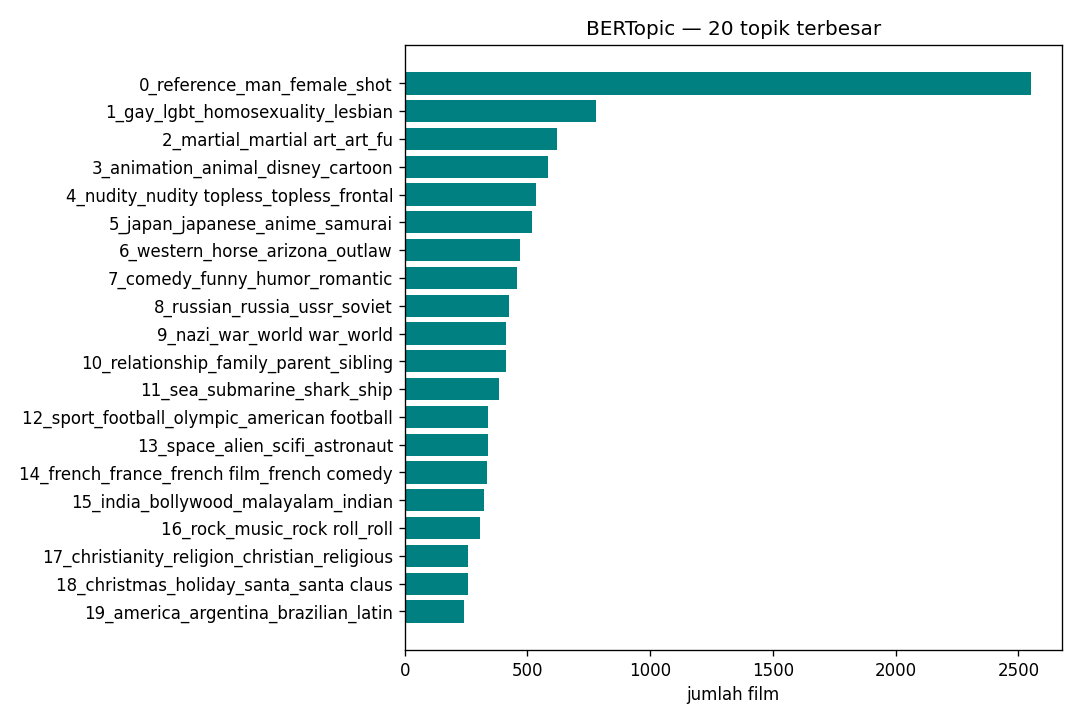

In [5]:
display(Image(filename=str(FIG / "25_bertopic_sizes.png")))


## 3. Semantic search via sentence-transformers + FAISS

Setiap tag-document dienkode dengan `all-MiniLM-L6-v2` (384-dim, L2-normalized)
-> `IndexFlatIP`. Query natural-language dibandingkan via cosine similarity.


In [6]:
demo = pd.read_csv(NLP / "semantic_search_demo.csv")
for q in demo['query'].unique():
    print(f"\n>> {q}")
    print(demo[demo['query'] == q][['rank', 'score', 'title']].to_string(index=False))



>> mind-bending time travel science fiction
 rank  score                                  title
    1  0.630 Beyond the Infinite Two Minutes (2020)
    2  0.602                     The Anomaly (2014)
    3  0.591                     Frequencies (2013)
    4  0.589                   Enter Nowhere (2011)
    5  0.586          Light Years (Gandahar) (1988)

>> feel good romantic comedy
 rank  score                           title
    1  0.757       Overnight Delivery (1998)
    2  0.721              The Clapper (2018)
    3  0.697              Matchmaking (2016)
    4  0.693       Ticket to Paradise (2022)
    5  0.670 Love Hina Spring Special (2001)

>> dark psychological thriller
 rank  score                             title
    1  0.718            Valley of Bones (2017)
    2  0.710                          Z (2019)
    3  0.700            May God Save Us (2016)
    4  0.689 Be My Cat: A Film for Anne (2015)
    5  0.680                   Darkland (2017)

>> epic space opera with ali

## 4. UMAP + HDBSCAN pada tag-genome (1128-dim)

Reduksi UMAP(cosine, n_neighbors=15) -> 2D, lalu HDBSCAN(min_cluster_size=40).
Catatan: genome embedding sudah cukup padat secara semantik sehingga HDBSCAN
pada default parameter hanya menemukan cluster besar (sisanya ter-labeli noise).
Untuk portfolio ini cluster utama terlihat jelas di scatter plot, tuning
parameter bisa ditambah di Fase 6 (ablation).


    cluster     n
0        -1  5940
1        25  3738
2         5   844
3         3   732
4        19   590
5        30   468
6        18   377
7        27   367
8        29   332
9        13   288
10       20   281
11       17   252
12        2   212
13        9   204
14        4   186
15        0   146
16        1   139
17       22   135
18        6   134
19        8   133
20       10   110
21       21   100
22       15    99
23       26    85
24       12    80
25        7    77
26       16    68
27       14    64
28       23    53
29       11    52
30       28    50
31       24    40


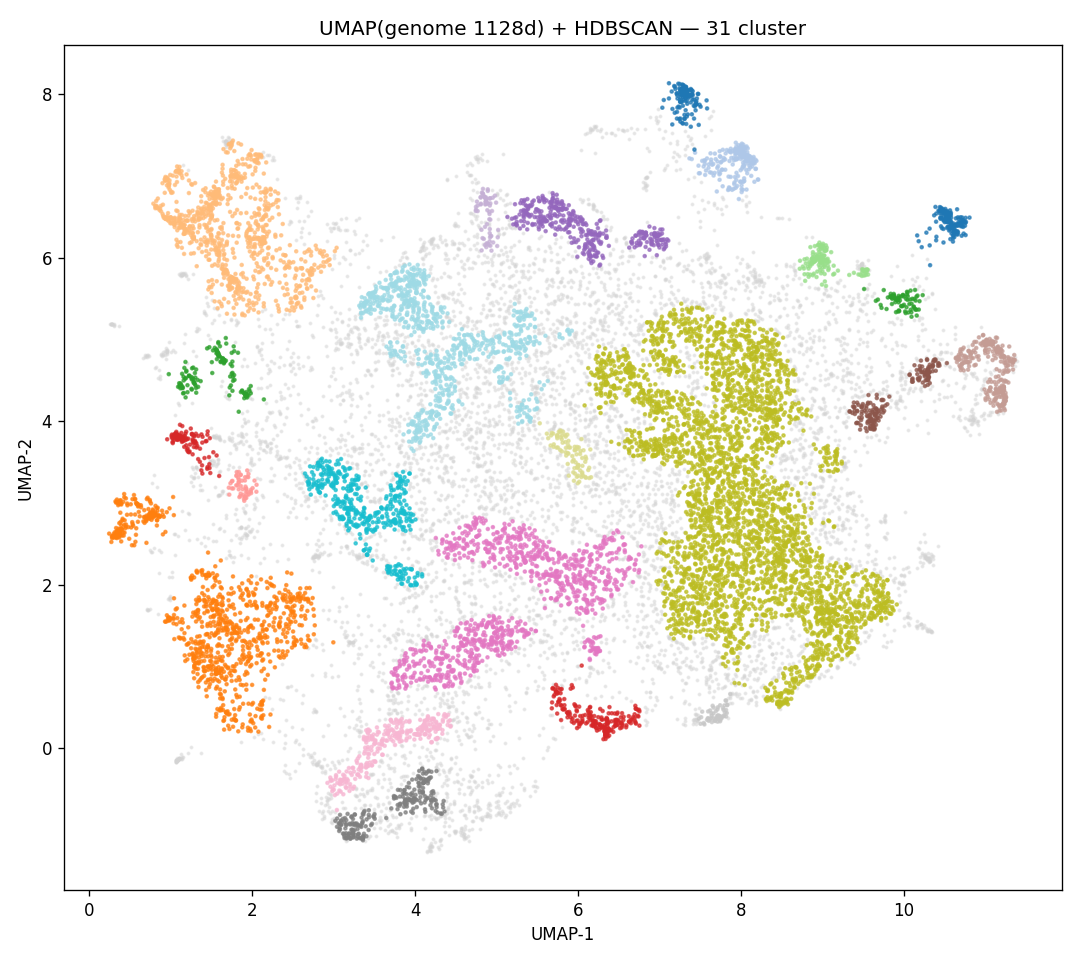

In [7]:
clusters = pl.read_parquet(NLP / "genome_clusters.parquet")
print(clusters.group_by('cluster').agg(pl.len().alias('n')).sort('n', descending=True).to_pandas())
display(Image(filename=str(FIG / "26_umap_genome.png")))


## 5. WordCloud per genre & co-occurrence network

WordCloud dibangun dari tag bersih yang difilter per genre utama.
Network tag top-80 menampilkan edge jika dua tag pernah muncul bersama
pada >= 40 film (edge width proporsional terhadap co-occurrence count).


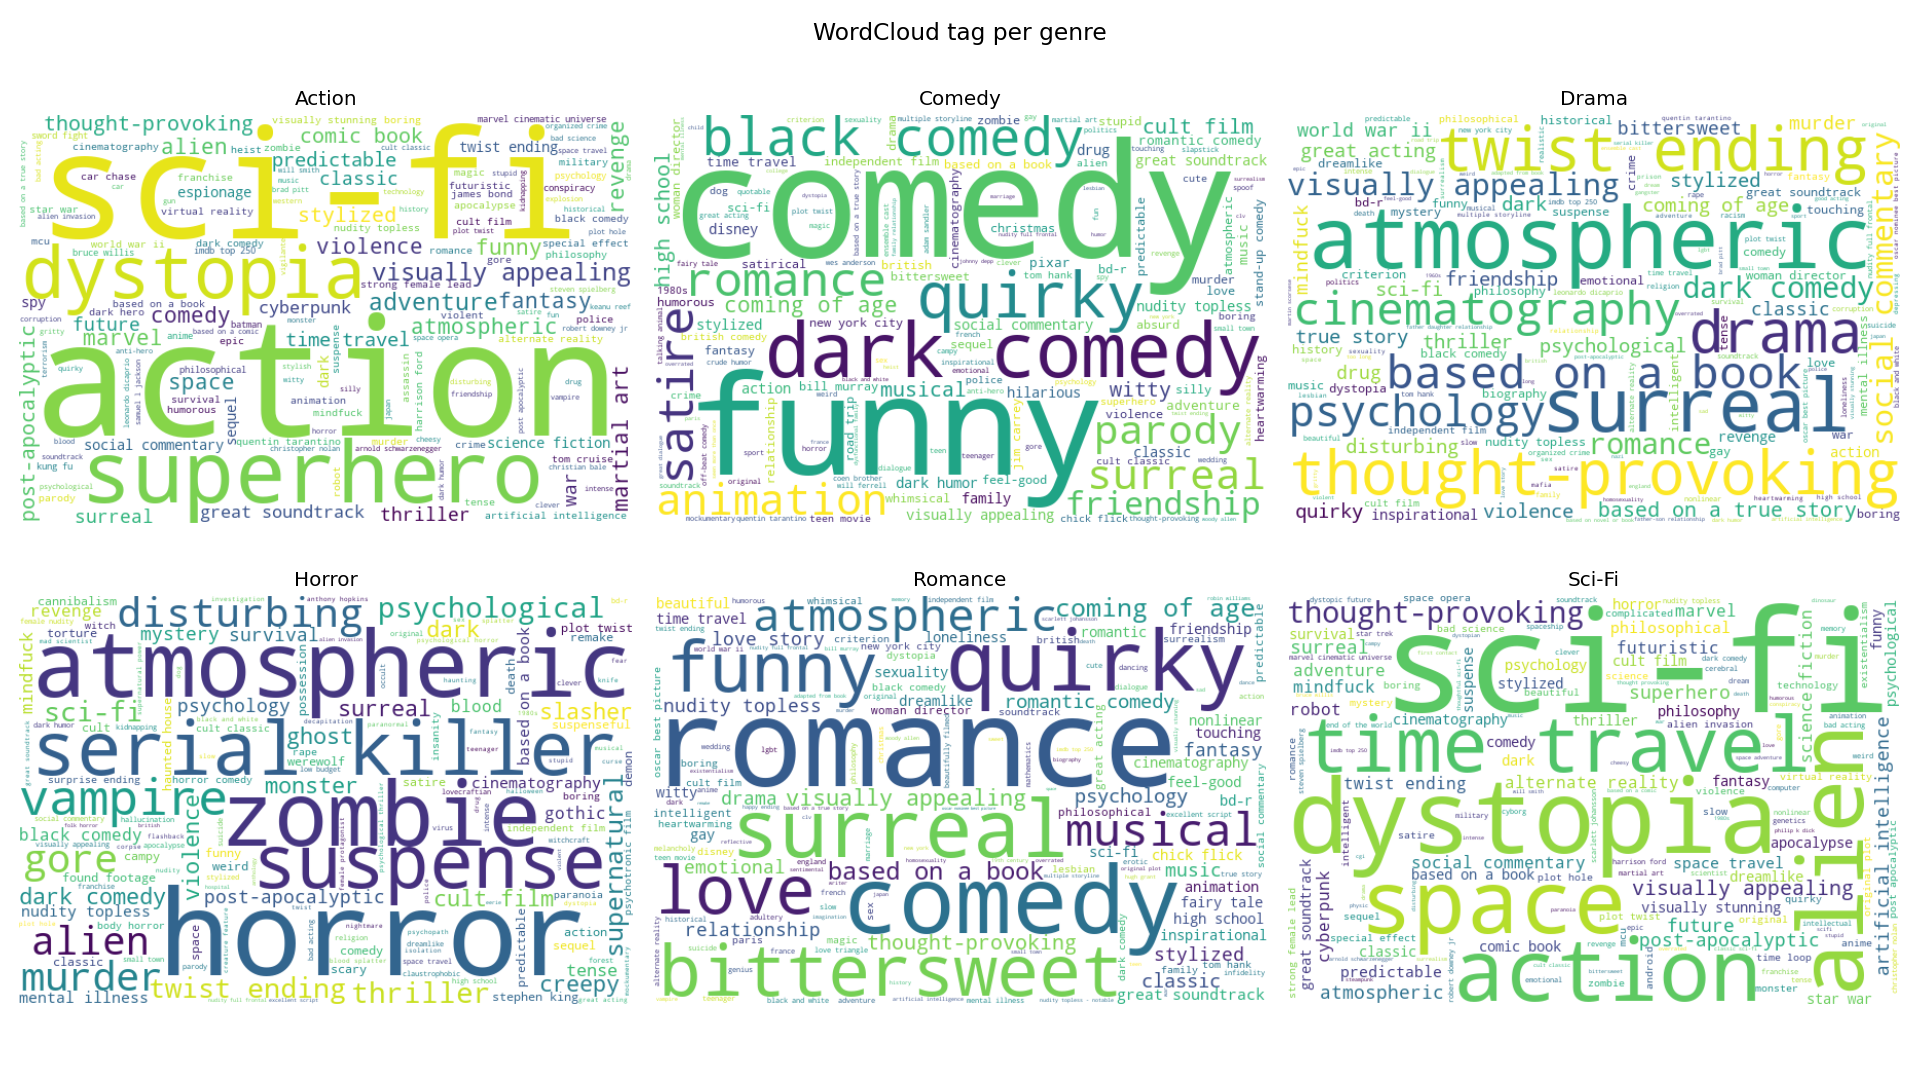

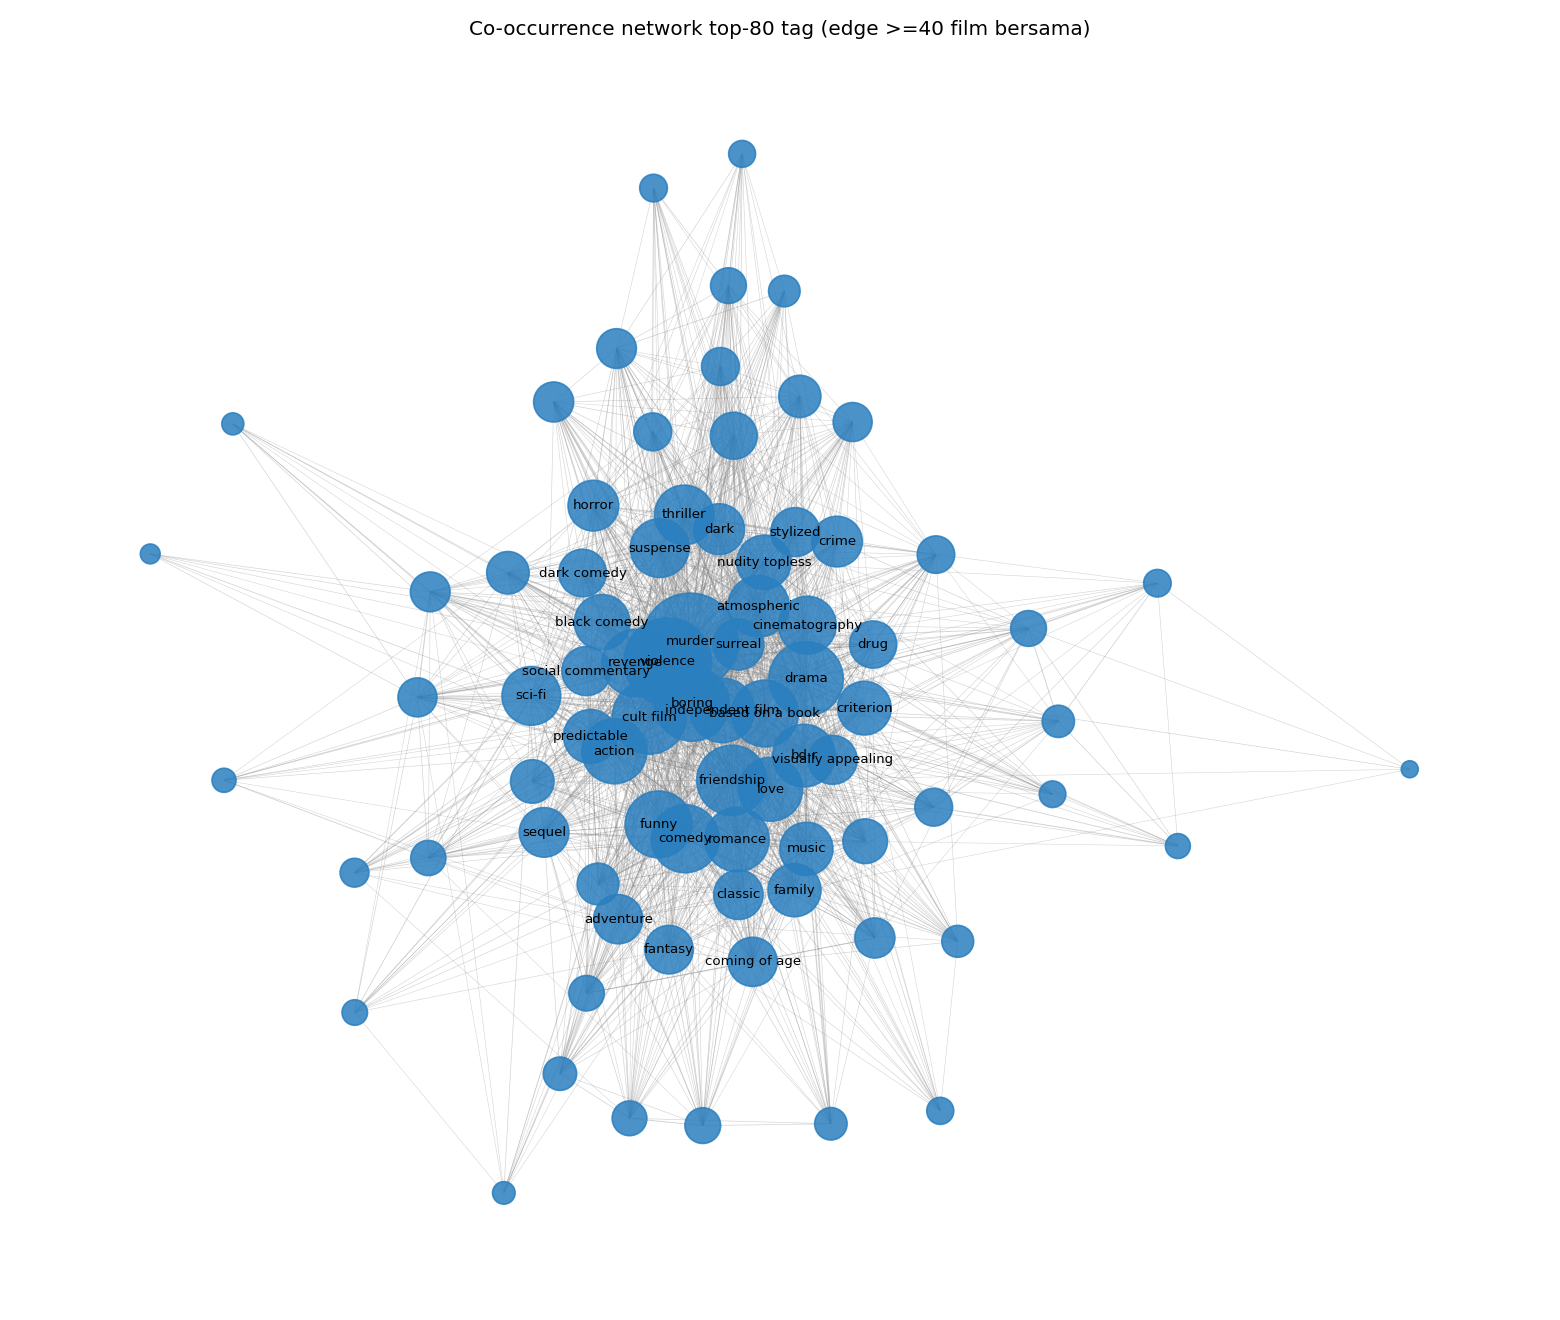

In [8]:
display(Image(filename=str(FIG / "27_wordcloud_genre.png")))
display(Image(filename=str(FIG / "28_tag_cooccurrence.png")))


## 6. Kesimpulan Fase 5

- **2.32M tag bebas** berhasil dibersihkan menjadi **40K tag-document** film.
- **BERTopic** menemukan **94 topik semantik** tanpa supervision, bisa dipakai
  sebagai fitur tambahan (topic id) untuk recommender hybrid di Fase 6.
- **Semantic search** demo menunjukkan retrieval relevan untuk query natural
  ("mind-bending time travel sci-fi", "dark psychological thriller", dst.).
  Bisa dipakai langsung di tab Streamlit Fase 8.
- **Genome UMAP** memperlihatkan manifold koheren; clustering halus menjadi
  agenda Fase 6 (ablation parameter HDBSCAN/min_cluster_size).
- Semua artefak (`tags_clean`, `movie_tag_docs`, `movie_text_embeddings.npy`,
  `movie_text.faiss`, `bertopic_topics`, `genome_clusters`) siap di-load oleh
  FastAPI & Streamlit di fase berikutnya.
